# Q-Learning vs DQN Analysis (Sparse 3 dB)

This notebook compares tabular Q-learning (RELDEC) and DQN variants using existing checkpoints.

Compared methods:
- tabular RELDEC
- deep RELDEC z=1
- deep RELDEC z=2
- deep RELDEC z=1 (constant epsilon = 0.6)
- deep RELDEC z=2 (constant epsilon = 0.6)

Key constraints:
- No retraining in this notebook
- Sparse milestone evaluation only
- Performance evaluation only at 3.0 dB
- BER/FER evaluation uses fewer frames than regular analysis

In [10]:
from pathlib import Path
import json
import re
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "RELDEC").exists() and (PROJECT_ROOT.parent / "RELDEC").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RELDEC_DIR = PROJECT_ROOT / "RELDEC"
ACTIVE_WRAN = RELDEC_DIR / "notebook_runs" / "continuous_reldec" / "active_run" / "wran"
TABULAR_CKPT_DIR = ACTIVE_WRAN / "checkpoints"
DEEP_CKPT_DIRS = {
    "deep_reldec_z1": ACTIVE_WRAN / "checkpoints_deep_z1_1k",
    "deep_reldec_z2": ACTIVE_WRAN / "checkpoints_deep_z2_1k",
    "deep_reldec_z1_eps06const": ACTIVE_WRAN / "checkpoints_deep_z1_1k_eps06const",
    "deep_reldec_z2_eps06const": ACTIVE_WRAN / "checkpoints_deep_z2_1k_eps06const",
}
MATRIX_CSV = RELDEC_DIR / "matrices" / "WRAN_irreg_384_256.csv"

ANALYSIS_ROOT = RELDEC_DIR / "notebook_runs" / "analysis_qlearning_vs_dqn_sparse"
RESULTS_DIR = ANALYSIS_ROOT / "results"
TMP_QTABLE_DIR = ANALYSIS_ROOT / "tmp_qtables"
for p in [ANALYSIS_ROOT, RESULTS_DIR, TMP_QTABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Keep BER/FER eval cheaper than normal analysis
REGULAR_MAX_FRAMES_REFERENCE = 3000
SPARSE_EVAL_MAX_FRAMES = 800
SPARSE_EVAL_TARGET_FRAME_ERRORS = 20
SPARSE_EVAL_SNR = 3.0
SPARSE_EVAL_SEED = 707
RUN_SPARSE_EVAL = True

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"TABULAR_CKPT_DIR={TABULAR_CKPT_DIR}")
for method, ckpt_dir in DEEP_CKPT_DIRS.items():
    print(f"{method} checkpoints: {ckpt_dir}")
print(f"SPARSE_EVAL_MAX_FRAMES={SPARSE_EVAL_MAX_FRAMES} (< {REGULAR_MAX_FRAMES_REFERENCE})")
print(f"RUN_SPARSE_EVAL={RUN_SPARSE_EVAL}")

PROJECT_ROOT=/root/Research/RithvikDecoder/Decoder
TABULAR_CKPT_DIR=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints
deep_reldec_z1 checkpoints: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z1_1k
deep_reldec_z2 checkpoints: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_1k
deep_reldec_z1_eps06const checkpoints: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z1_1k_eps06const
deep_reldec_z2_eps06const checkpoints: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_1k_eps06const
SPARSE_EVAL_MAX_FRAMES=800 (< 3000)
RUN_SPARSE_EVAL=True


In [20]:
def _episode_from_path(p: Path) -> int:
    m = re.search(r"ep(\d+)", p.stem)
    if m:
        return int(m.group(1))
    if "final" in p.stem:
        return 10**12
    if "latest" in p.stem:
        return 10**12 - 1
    return 0

def _sorted_checkpoints(ckpt_dir: Path) -> list[Path]:
    files = []
    for pattern in ("checkpoint_ep*.npz", "checkpoint_latest.npz", "checkpoint_final.npz"):
        for p in ckpt_dir.glob(pattern):
            if p.is_file():
                files.append(p)
    files = sorted({p.resolve(): p for p in files}.values(), key=_episode_from_path)
    return files

def _progress_from_npz(npz_path: Path) -> dict:
    with np.load(npz_path, allow_pickle=False) as npz:
        return {
            "episodes_completed": int(np.asarray(npz["episodes_completed"]).reshape(-1)[0]),
            "total_updates": int(np.asarray(npz["total_updates"]).reshape(-1)[0]),
            "reward_sum": float(np.asarray(npz["reward_sum"]).reshape(-1)[0]),
            "reward_count": int(np.asarray(npz["reward_count"]).reshape(-1)[0]),
            "mean_reward": float(np.asarray(npz["reward_sum"]).reshape(-1)[0]) / max(int(np.asarray(npz["reward_count"]).reshape(-1)[0]), 1),
            "global_step": int(np.asarray(npz["global_step"]).reshape(-1)[0]) if "global_step" in npz.files else None,
        }

def _milestones(paths: list[Path], max_points: int = 10) -> list[Path]:
    if not paths or max_points <= 0:
        return []
    if len(paths) <= max_points:
        return paths

    # Evenly sample checkpoints across the full trajectory, always including both ends.
    idx = np.linspace(0, len(paths) - 1, num=max_points, dtype=int)
    idx = sorted(set(int(i) for i in idx))
    if idx[-1] != len(paths) - 1:
        idx.append(len(paths) - 1)
    return [paths[i] for i in idx]

In [21]:
tab_ckpts = _sorted_checkpoints(TABULAR_CKPT_DIR)
deep_ckpts_by_method = {
    method: _sorted_checkpoints(ckpt_dir)
    for method, ckpt_dir in DEEP_CKPT_DIRS.items()
}

print(f"tabular checkpoints: {len(tab_ckpts)}")
for method, ckpts in deep_ckpts_by_method.items():
    print(f"{method} checkpoints: {len(ckpts)}")

rows = []
for p in tab_ckpts:
    prog = _progress_from_npz(p)
    rows.append({"method": "tabular_reldec", "checkpoint": p.name, **prog})
for method, ckpts in deep_ckpts_by_method.items():
    for p in ckpts:
        prog = _progress_from_npz(p)
        rows.append({"method": method, "checkpoint": p.name, **prog})

progress_df = pd.DataFrame(rows)
progress_df = progress_df.sort_values(["method", "episodes_completed", "checkpoint"]).reset_index(drop=True)
display(progress_df.head(12))
display(progress_df.groupby("method")["episodes_completed"].agg(["min", "max", "count"]))

tabular checkpoints: 62
deep_reldec_z1 checkpoints: 22
deep_reldec_z2 checkpoints: 22
deep_reldec_z1_eps06const checkpoints: 22
deep_reldec_z2_eps06const checkpoints: 22


,method,checkpoint,episodes_completed,total_updates,reward_sum,reward_count,mean_reward,global_step
0,deep_reldec_z1,checkpoint_ep000050.npz,50,1000,949.409091,1000,0.949409,1000.0
1,deep_reldec_z1,checkpoint_ep000100.npz,100,2000,1921.918182,2000,0.960959,2000.0
2,deep_reldec_z1,checkpoint_ep000150.npz,150,3000,2899.745455,3000,0.966582,3000.0
3,deep_reldec_z1,checkpoint_ep000200.npz,200,4000,3867.418182,4000,0.966855,4000.0
4,deep_reldec_z1,checkpoint_ep000250.npz,250,5000,4843.118182,5000,0.968624,5000.0
5,deep_reldec_z1,checkpoint_ep000300.npz,300,6000,5803.318182,6000,0.967220,6000.0
6,deep_reldec_z1,checkpoint_ep000350.npz,350,7000,6770.836364,7000,0.967262,7000.0
7,deep_reldec_z1,checkpoint_ep000400.npz,400,8000,7755.227273,8000,0.969403,8000.0
8,deep_reldec_z1,checkpoint_ep000450.npz,450,9000,8740.618182,9000,0.971180,9000.0
9,deep_reldec_z1,checkpoint_ep000500.npz,500,10000,9725.809091,10000,0.972581,10000.0


,min,max,count
method,,,
deep_reldec_z1,50,1000,22
deep_reldec_z1_eps06const,50,1000,22
deep_reldec_z2,50,1000,22
deep_reldec_z2_eps06const,50,1000,22
tabular_reldec,250,15000,62


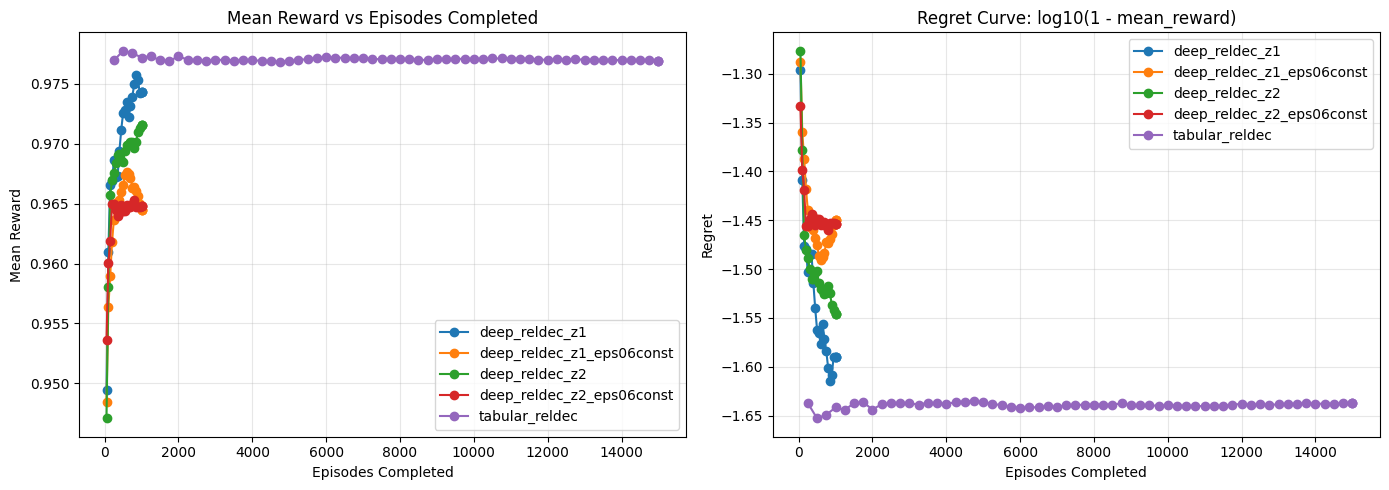

In [13]:
if progress_df.empty:
    raise RuntimeError("No checkpoints found for analysis.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method, g in progress_df.groupby("method"):
    g = g.sort_values("episodes_completed")
    axes[0].plot(g["episodes_completed"], g["mean_reward"], marker="o", label=method)

    # Regret transform requested: regret = log10(1 - mean_reward)
    safe = np.clip(1.0 - g["mean_reward"].to_numpy(dtype=float), 1e-12, None)
    regret = np.log10(safe)
    axes[1].plot(g["episodes_completed"], regret, marker="o", label=method)

axes[0].set_title("Mean Reward vs Episodes Completed")
axes[0].set_xlabel("Episodes Completed")
axes[0].set_ylabel("Mean Reward")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Regret Curve: log10(1 - mean_reward)")
axes[1].set_xlabel("Episodes Completed")
axes[1].set_ylabel("Regret")
axes[1].grid(True, alpha=0.3)

axes[0].legend(loc="best")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

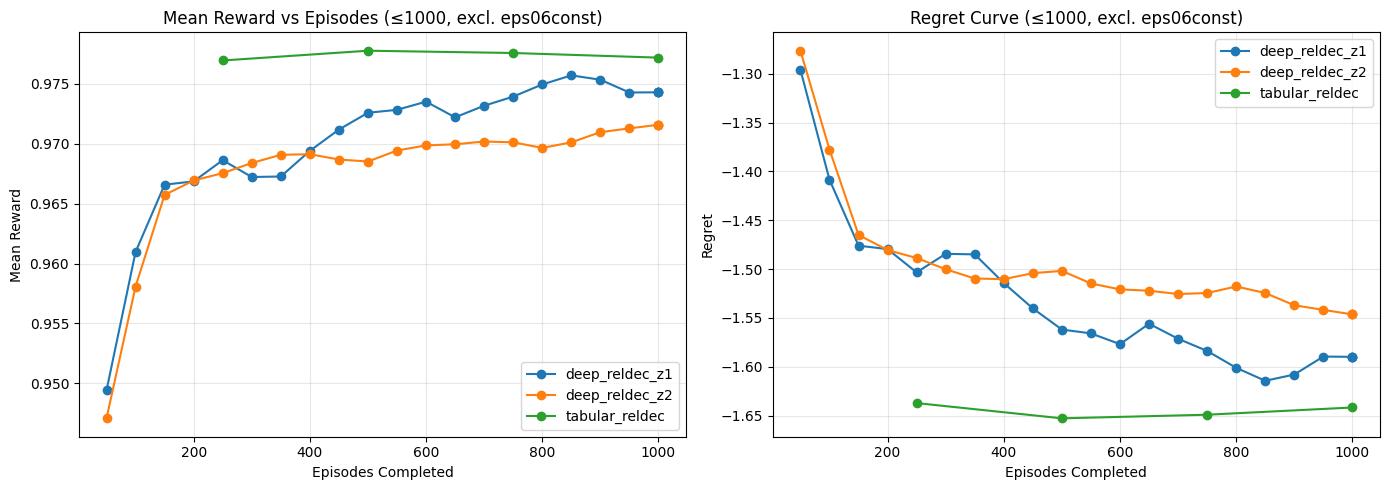

In [27]:
if progress_df.empty:
    raise RuntimeError("No checkpoints found for analysis.")

# Clipped version: only 1000 episodes, exclude constant-epsilon methods
progress_clipped = progress_df[
    (~progress_df["method"].str.contains("eps06const", na=False))
    & (progress_df["episodes_completed"] <= 1000)
].copy()

if progress_clipped.empty:
    print("No data available after filtering.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for method, g in progress_clipped.groupby("method"):
        g = g.sort_values("episodes_completed")
        axes[0].plot(g["episodes_completed"], g["mean_reward"], marker="o", label=method)

        # Regret transform: regret = log10(1 - mean_reward)
        safe = np.clip(1.0 - g["mean_reward"].to_numpy(dtype=float), 1e-12, None)
        regret = np.log10(safe)
        axes[1].plot(g["episodes_completed"], regret, marker="o", label=method)

    axes[0].set_title("Mean Reward vs Episodes (≤1000, excl. eps06const)")
    axes[0].set_xlabel("Episodes Completed")
    axes[0].set_ylabel("Mean Reward")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Regret Curve (≤1000, excl. eps06const)")
    axes[1].set_xlabel("Episodes Completed")
    axes[1].set_ylabel("Regret")
    axes[1].grid(True, alpha=0.3)

    axes[0].legend(loc="best")
    axes[1].legend(loc="best")
    plt.tight_layout()
    plt.show()

,checkpoint,episodes_completed,probe_id,state,action,q_value
0,checkpoint_ep000250.npz,250,0,31,87,0.0
1,checkpoint_ep000250.npz,250,1,1214,6,0.0
2,checkpoint_ep000250.npz,250,2,1861,28,0.0
3,checkpoint_ep000250.npz,250,3,522,23,0.0
4,checkpoint_ep000250.npz,250,4,683,22,0.0


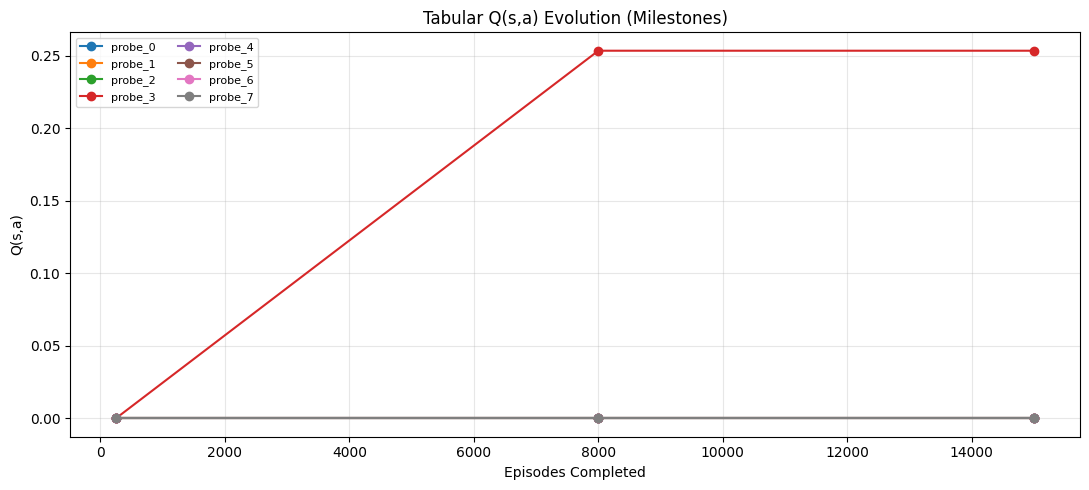

In [14]:
rng = np.random.default_rng(123)
tab_milestones = _milestones(tab_ckpts, max_points=3)

if not tab_milestones:
    print("No tabular milestone checkpoints found.")
else:
    with np.load(tab_milestones[-1], allow_pickle=False) as npz:
        q_shape = np.asarray(npz["q_table"]).shape

    n_states, n_actions = q_shape
    probe_pairs = [
        (int(rng.integers(0, n_states)), int(rng.integers(0, n_actions)))
        for _ in range(8)
    ]

    tab_probe_rows = []
    for ck in tab_milestones:
        ep = _episode_from_path(ck)
        with np.load(ck, allow_pickle=False) as npz:
            q = np.asarray(npz["q_table"], dtype=np.float64)
        for i, (s, a) in enumerate(probe_pairs):
            tab_probe_rows.append({
                "checkpoint": ck.name,
                "episodes_completed": int(np.asarray(np.load(ck, allow_pickle=False)["episodes_completed"]).reshape(-1)[0]),
                "probe_id": i,
                "state": s,
                "action": a,
                "q_value": float(q[s, a]),
            })

    tab_probe_df = pd.DataFrame(tab_probe_rows)
    display(tab_probe_df.head())

    fig, ax = plt.subplots(figsize=(11, 5))
    for pid, g in tab_probe_df.groupby("probe_id"):
        g = g.sort_values("episodes_completed")
        ax.plot(g["episodes_completed"], g["q_value"], marker="o", label=f"probe_{pid}")
    ax.set_title("Tabular Q(s,a) Evolution (Milestones)")
    ax.set_xlabel("Episodes Completed")
    ax.set_ylabel("Q(s,a)")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

,analysis_method,checkpoint,episodes_completed,probe_id,q_value
0,deep_reldec_z1,checkpoint_ep000050.npz,50,0,0.278473
1,deep_reldec_z1,checkpoint_ep000050.npz,50,1,0.198726
2,deep_reldec_z1,checkpoint_ep000050.npz,50,2,0.174430
3,deep_reldec_z1,checkpoint_ep000050.npz,50,3,0.212168
4,deep_reldec_z1,checkpoint_ep000050.npz,50,4,0.368935


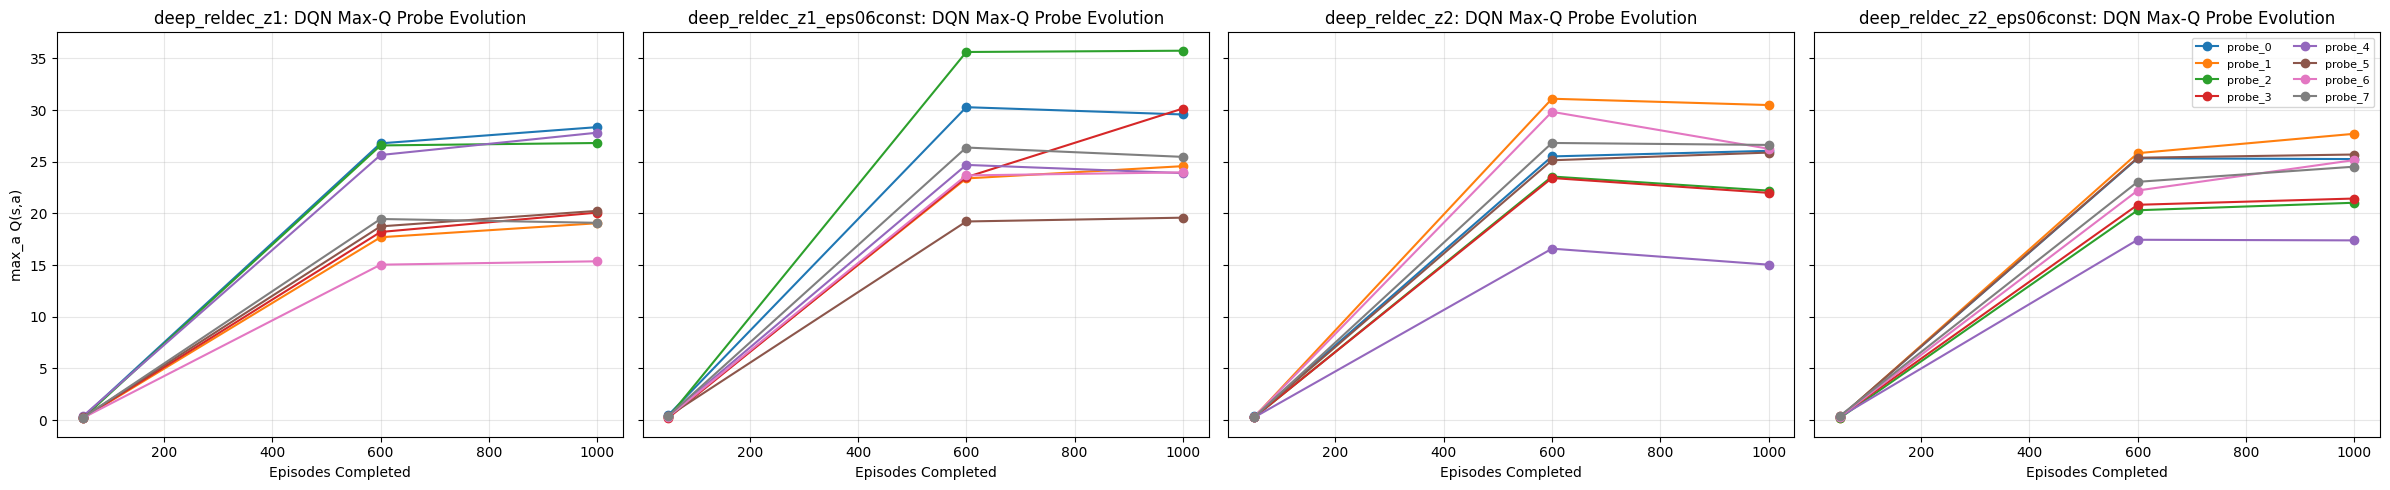

In [15]:
from reldec_core import load_parity_check_from_sparse_csv
from reldec_deep import load_deep_training_checkpoint, DeepReldecTrainer
import torch

def _resolve_project_path(p: str | Path) -> Path:
    p = Path(p)
    return p if p.is_absolute() else (PROJECT_ROOT / p)

deep_milestones_by_method = {
    method: _milestones(ckpts, max_points=3)
    for method, ckpts in deep_ckpts_by_method.items()
}
deep_milestones_by_method = {m: v for m, v in deep_milestones_by_method.items() if v}

if not deep_milestones_by_method:
    print("No deep milestone checkpoints found.")
else:
    deep_probe_rows = []
    deep_probe_states_by_method = {}

    for method, deep_milestones in deep_milestones_by_method.items():
        first_ckpt = load_deep_training_checkpoint(deep_milestones[0])
        H = load_parity_check_from_sparse_csv(_resolve_project_path(first_ckpt.config.matrix_csv))

        trainer_probe = DeepReldecTrainer(
            h_csr=H,
            dqn_config=first_ckpt.dqn_config,
            beta_discount=first_ckpt.config.hyperparams.beta,
            l_max=first_ckpt.config.hyperparams.l_max,
            device="cpu",
        )

        probe_seed = 321 if method == "deep_reldec_z1" else 654
        probe_rng = np.random.default_rng(probe_seed)
        probe_states = probe_rng.normal(
            loc=0.0,
            scale=1.0,
            size=(24, trainer_probe.state_dim),
        ).astype(np.float32)
        deep_probe_states_by_method[method] = probe_states

        for ck_path in deep_milestones:
            ck = load_deep_training_checkpoint(ck_path)
            trainer = DeepReldecTrainer(
                h_csr=H,
                dqn_config=ck.dqn_config,
                beta_discount=ck.config.hyperparams.beta,
                l_max=ck.config.hyperparams.l_max,
                device="cpu",
            )
            trainer.import_checkpoint_payload(
                ck.q_online_bytes,
                ck.q_target_bytes,
                ck.optimizer_bytes,
                ck.global_step,
            )

            with torch.no_grad():
                inp = torch.as_tensor(probe_states, dtype=torch.float32, device=trainer.device)
                q_vals = trainer.online_net(inp).cpu().numpy()

            for pid in range(min(8, probe_states.shape[0])):
                deep_probe_rows.append({
                    "analysis_method": method,
                    "checkpoint": ck_path.name,
                    "episodes_completed": int(ck.progress.episodes_completed),
                    "probe_id": pid,
                    "q_value": float(np.max(q_vals[pid])),
                })

    deep_probe_df = pd.DataFrame(deep_probe_rows)
    display(deep_probe_df.head())

    methods = sorted(deep_probe_df["analysis_method"].unique())
    fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5), sharey=True)
    if len(methods) == 1:
        axes = [axes]

    for ax, method in zip(axes, methods):
        view = deep_probe_df[deep_probe_df["analysis_method"] == method]
        for pid, g in view.groupby("probe_id"):
            g = g.sort_values("episodes_completed")
            ax.plot(g["episodes_completed"], g["q_value"], marker="o", label=f"probe_{pid}")
        ax.set_title(f"{method}: DQN Max-Q Probe Evolution")
        ax.set_xlabel("Episodes Completed")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("max_a Q(s,a)")
    axes[-1].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

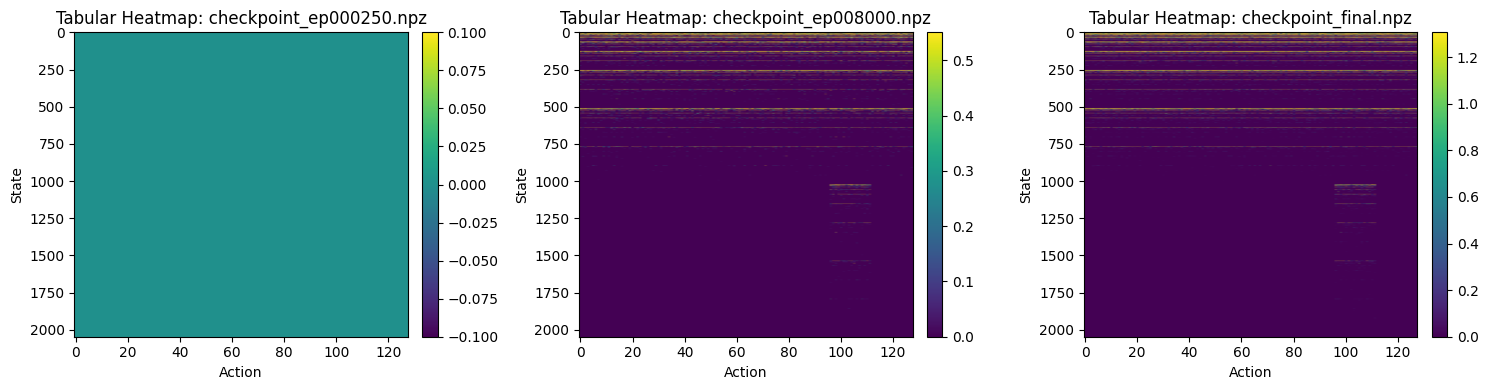

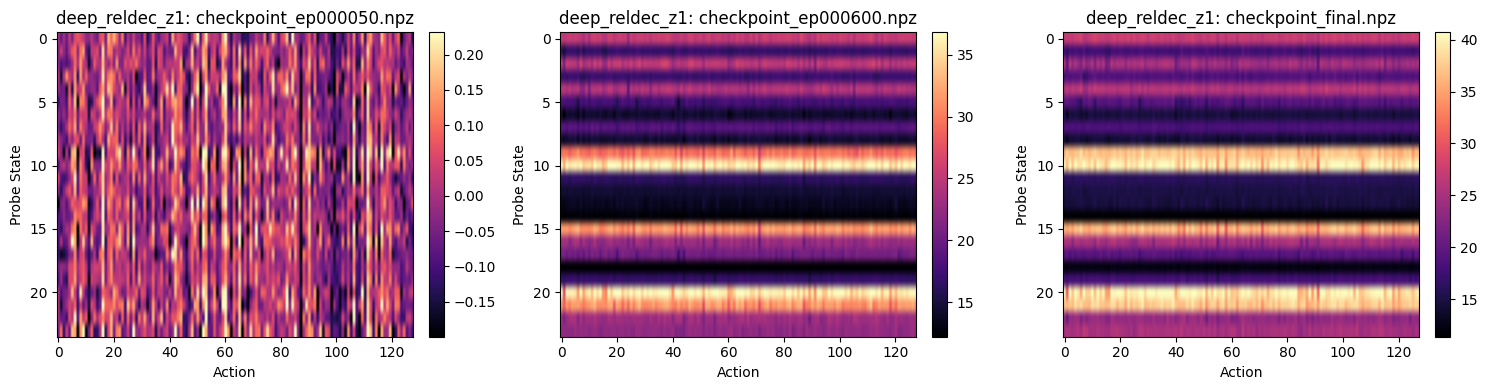

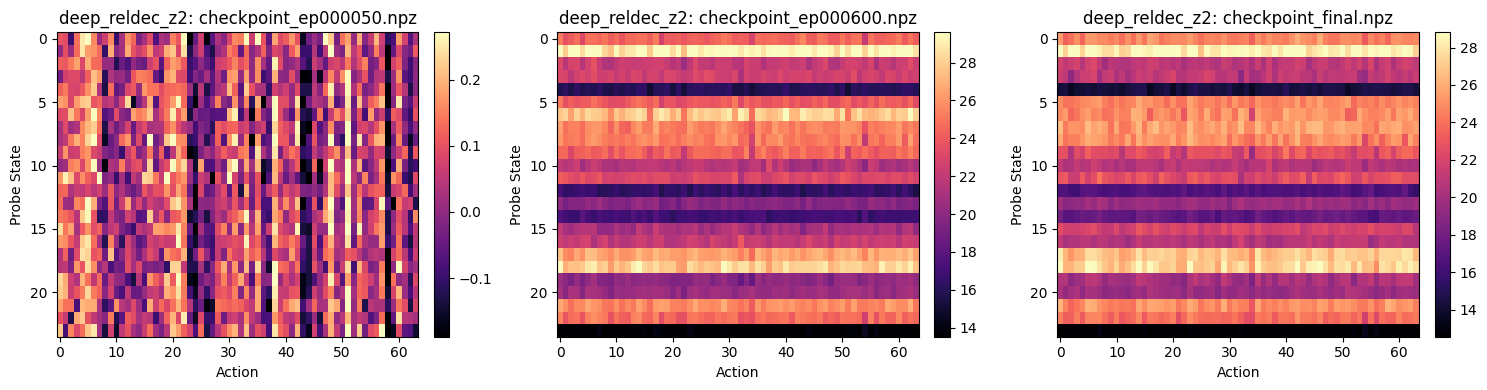

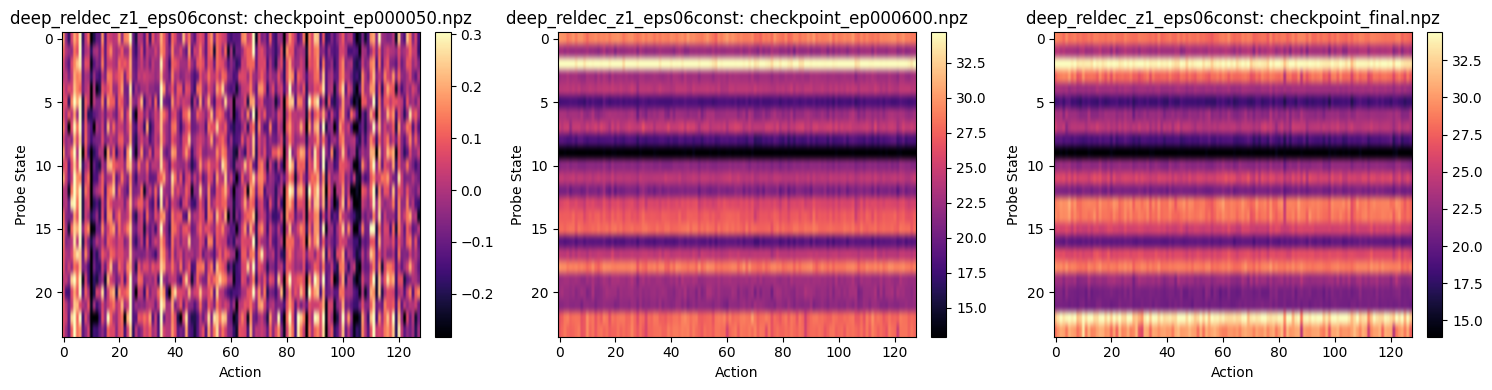

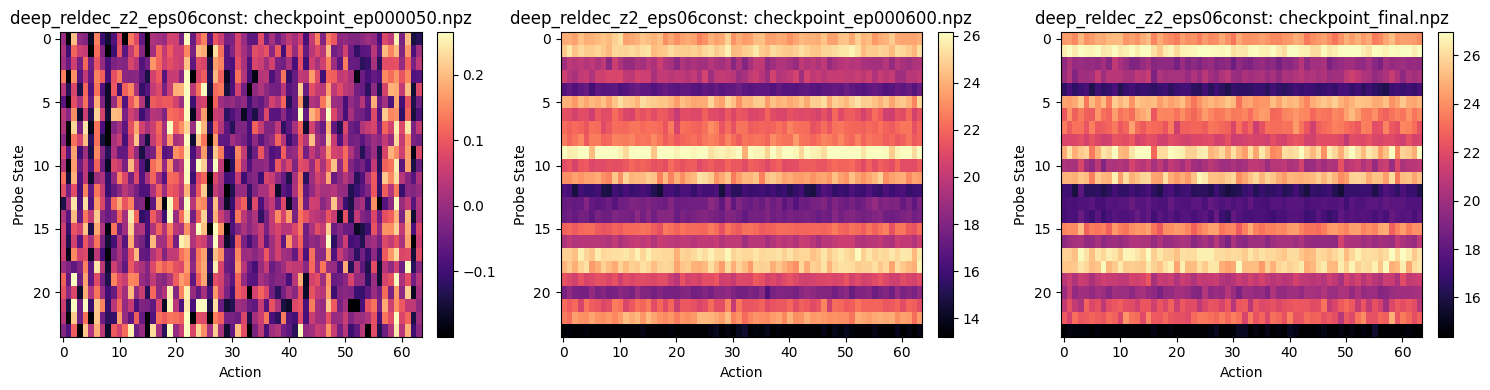

In [16]:
# Heatmaps: tabular q_table and DQN probe-state action-values
if tab_milestones:
    fig, axes = plt.subplots(1, len(tab_milestones), figsize=(5 * len(tab_milestones), 4))
    if len(tab_milestones) == 1:
        axes = [axes]
    for ax, ck in zip(axes, tab_milestones):
        with np.load(ck, allow_pickle=False) as npz:
            q = np.asarray(npz["q_table"], dtype=np.float64)
        clipped = np.clip(q, np.percentile(q, 2), np.percentile(q, 98))
        im = ax.imshow(clipped, aspect="auto", cmap="viridis")
        ax.set_title(f"Tabular Heatmap: {ck.name}")
        ax.set_xlabel("Action")
        ax.set_ylabel("State")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

if deep_milestones_by_method:
    for method, deep_milestones in deep_milestones_by_method.items():
        fig, axes = plt.subplots(1, len(deep_milestones), figsize=(5 * len(deep_milestones), 4))
        if len(deep_milestones) == 1:
            axes = [axes]

        probe_states = deep_probe_states_by_method.get(method)
        if probe_states is None:
            first_ckpt = load_deep_training_checkpoint(deep_milestones[0])
            trainer_probe = DeepReldecTrainer(
                h_csr=load_parity_check_from_sparse_csv(_resolve_project_path(first_ckpt.config.matrix_csv)),
                dqn_config=first_ckpt.dqn_config,
                beta_discount=first_ckpt.config.hyperparams.beta,
                l_max=first_ckpt.config.hyperparams.l_max,
                device="cpu",
            )
            probe_seed = 321 if method == "deep_reldec_z1" else 654
            probe_rng = np.random.default_rng(probe_seed)
            probe_states = probe_rng.normal(
                loc=0.0,
                scale=1.0,
                size=(24, trainer_probe.state_dim),
            ).astype(np.float32)

        for ax, ck_path in zip(axes, deep_milestones):
            ck = load_deep_training_checkpoint(ck_path)
            trainer = DeepReldecTrainer(
                h_csr=load_parity_check_from_sparse_csv(_resolve_project_path(ck.config.matrix_csv)),
                dqn_config=ck.dqn_config,
                beta_discount=ck.config.hyperparams.beta,
                l_max=ck.config.hyperparams.l_max,
                device="cpu",
            )
            trainer.import_checkpoint_payload(
                ck.q_online_bytes,
                ck.q_target_bytes,
                ck.optimizer_bytes,
                ck.global_step,
            )
            with torch.no_grad():
                q_vals = trainer.online_net(torch.as_tensor(probe_states, dtype=torch.float32)).cpu().numpy()
            clipped = np.clip(q_vals, np.percentile(q_vals, 2), np.percentile(q_vals, 98))
            im = ax.imshow(clipped, aspect="auto", cmap="magma")
            ax.set_title(f"{method}: {ck_path.name}")
            ax.set_xlabel("Action")
            ax.set_ylabel("Probe State")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

Reusing existing sparse BER rows from: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/analysis_qlearning_vs_dqn_sparse/results/sparse_3db_summary.csv
Target evaluation points per method: 10
tabular_reldec -> 10 checkpoints
deep_reldec_z1 -> 10 checkpoints
deep_reldec_z2 -> 10 checkpoints
deep_reldec_z1_eps06const -> 10 checkpoints
deep_reldec_z2_eps06const -> 10 checkpoints
cd /root/Research/RithvikDecoder/Decoder && python RELDEC/evaluate_reldec.py --code wran --matrix-csv /root/Research/RithvikDecoder/Decoder/RELDEC/matrices/WRAN_irreg_384_256.csv --methods reldec --target-frame-errors 20 --max-frames 800 --seed 707 --snr-db 3.0 --output-csv /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/analysis_qlearning_vs_dqn_sparse/results/sparse_3db_reldec_ep001750.csv --output-json /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/analysis_qlearning_vs_dqn_sparse/results/sparse_3db_reldec_ep001750.json --q-table /root/Research/RithvikDecoder/Decoder/RELDEC/note

,method,snr_db,frames,bit_errors,frame_errors,ber,fer,avg_messages,avg_iterations,converged_frames,...,matrix_csv,code_rate,i_max,target_frame_errors,max_frames,all_zero_only,checkpoint,analysis_method,episodes_completed,reused_from_cache
0,deep_reldec_z1,3.0,266,271,20,0.002653,0.075188,3546.947368,2.736842,246,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000050.npz,deep_reldec_z1,50,True
1,deep_reldec_z1,3.0,800,66,6,0.000215,0.007500,2577.420000,1.988750,794,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000150.npz,deep_reldec_z1,150,False
2,deep_reldec_z1,3.0,800,103,9,0.000335,0.011250,2548.260000,1.966250,791,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000250.npz,deep_reldec_z1,250,False
3,deep_reldec_z1,3.0,800,136,10,0.000443,0.012500,2523.960000,1.947500,790,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000400.npz,deep_reldec_z1,400,False
4,deep_reldec_z1,3.0,800,136,10,0.000443,0.012500,2601.720000,2.007500,790,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000500.npz,deep_reldec_z1,500,False
5,deep_reldec_z1,3.0,800,112,11,0.000365,0.013750,2613.060000,2.016250,789,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000600.npz,deep_reldec_z1,600,True
6,deep_reldec_z1,3.0,800,104,7,0.000339,0.008750,2498.040000,1.927500,793,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000750.npz,deep_reldec_z1,750,False
7,deep_reldec_z1,3.0,800,130,9,0.000423,0.011250,2637.360000,2.035000,791,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000850.npz,deep_reldec_z1,850,False
8,deep_reldec_z1,3.0,800,95,7,0.000309,0.008750,2493.180000,1.923750,793,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_ep000950.npz,deep_reldec_z1,950,False
9,deep_reldec_z1,3.0,800,128,10,0.000417,0.012500,2561.220000,1.976250,790,...,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,20,800,True,checkpoint_final.npz,deep_reldec_z1,1000,True


,analysis_method,episodes_completed,progress,checkpoint,method,snr_db,ber,fer,avg_messages,frames,frame_errors,reused_from_cache
0,deep_reldec_z1,50,0.050000,checkpoint_ep000050.npz,deep_reldec_z1,3.0,0.002653,0.075188,3546.947368,266,20,True
1,deep_reldec_z1,150,0.150000,checkpoint_ep000150.npz,deep_reldec_z1,3.0,0.000215,0.007500,2577.420000,800,6,False
2,deep_reldec_z1,250,0.250000,checkpoint_ep000250.npz,deep_reldec_z1,3.0,0.000335,0.011250,2548.260000,800,9,False
3,deep_reldec_z1,400,0.400000,checkpoint_ep000400.npz,deep_reldec_z1,3.0,0.000443,0.012500,2523.960000,800,10,False
4,deep_reldec_z1,500,0.500000,checkpoint_ep000500.npz,deep_reldec_z1,3.0,0.000443,0.012500,2601.720000,800,10,False
5,deep_reldec_z1,600,0.600000,checkpoint_ep000600.npz,deep_reldec_z1,3.0,0.000365,0.013750,2613.060000,800,11,True
6,deep_reldec_z1,750,0.750000,checkpoint_ep000750.npz,deep_reldec_z1,3.0,0.000339,0.008750,2498.040000,800,7,False
7,deep_reldec_z1,850,0.850000,checkpoint_ep000850.npz,deep_reldec_z1,3.0,0.000423,0.011250,2637.360000,800,9,False
8,deep_reldec_z1,950,0.950000,checkpoint_ep000950.npz,deep_reldec_z1,3.0,0.000309,0.008750,2493.180000,800,7,False
9,deep_reldec_z1,1000,1.000000,checkpoint_final.npz,deep_reldec_z1,3.0,0.000417,0.012500,2561.220000,800,10,True


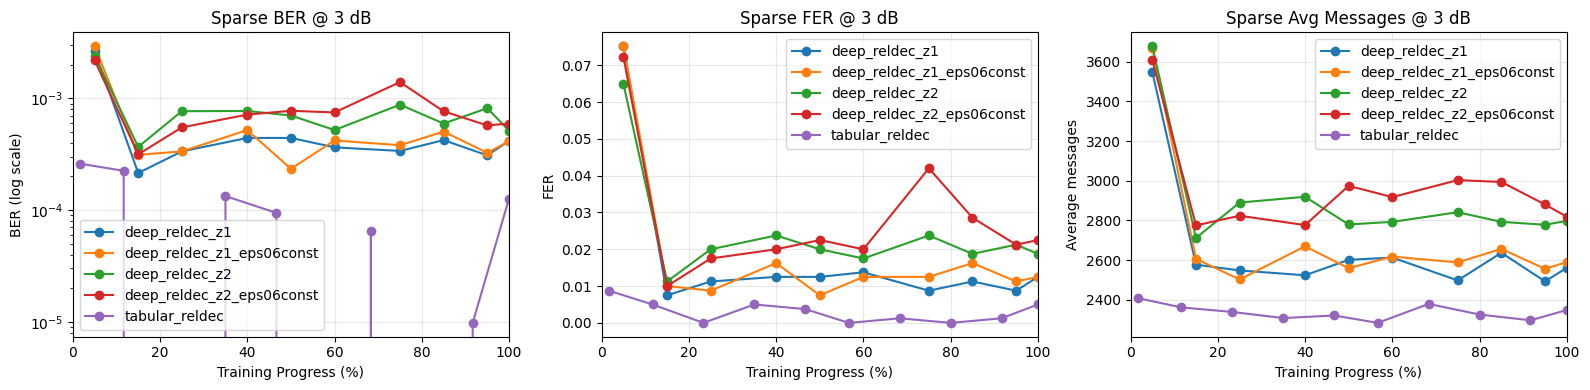

Done. This notebook runs offline analyses from existing checkpoints.


In [22]:
def _export_qtable_from_checkpoint(tab_ckpt: Path, out_npy: Path) -> Path:
    with np.load(tab_ckpt, allow_pickle=False) as npz:
        q = np.asarray(npz["q_table"], dtype=np.float64)
    np.save(out_npy, q)
    return out_npy


def _eval_method_for_analysis_method(analysis_method: str) -> str:
    if analysis_method == "tabular_reldec":
        return "reldec"
    if "deep_reldec_z1" in analysis_method:
        return "deep_reldec_z1"
    if "deep_reldec_z2" in analysis_method:
        return "deep_reldec_z2"
    raise ValueError(f"Unsupported analysis_method={analysis_method}")


def _run_sparse_eval(eval_method: str, checkpoint_path: Path, output_prefix: str, tabular_qtable_path: Path | None = None):
    out_csv = RESULTS_DIR / f"{output_prefix}.csv"
    out_json = RESULTS_DIR / f"{output_prefix}.json"

    cmd = [
        "cd", str(PROJECT_ROOT), "&&",
        "python", "RELDEC/evaluate_reldec.py",
        "--code", "wran",
        "--matrix-csv", str(MATRIX_CSV),
        "--methods", eval_method,
        "--target-frame-errors", str(SPARSE_EVAL_TARGET_FRAME_ERRORS),
        "--max-frames", str(SPARSE_EVAL_MAX_FRAMES),
        "--seed", str(SPARSE_EVAL_SEED),
        "--snr-db", str(SPARSE_EVAL_SNR),
        "--output-csv", str(out_csv),
        "--output-json", str(out_json),
    ]

    if eval_method == "reldec":
        if tabular_qtable_path is None:
            raise ValueError("tabular_qtable_path is required for eval_method='reldec'")
        cmd.extend(["--q-table", str(tabular_qtable_path)])

    if eval_method.startswith("deep_reldec_"):
        cmd.extend(["--deep-checkpoint", str(checkpoint_path)])

    shell_cmd = " ".join(cmd)
    print(shell_cmd)
    subprocess.run(["bash", "-lc", shell_cmd], cwd=str(PROJECT_ROOT), check=True)
    return out_csv, out_json


def _reuse_if_available(existing_df: pd.DataFrame, analysis_method: str, checkpoint_name: str) -> pd.DataFrame | None:
    if existing_df.empty:
        return None
    mask = (
        (existing_df["analysis_method"].astype(str) == str(analysis_method))
        & (existing_df["checkpoint"].astype(str) == str(checkpoint_name))
    )
    if not mask.any():
        return None
    reused = existing_df.loc[mask].copy()
    reused["reused_from_cache"] = True
    return reused


summary_csv = RESULTS_DIR / "sparse_3db_summary.csv"
existing_sparse_eval_df = pd.read_csv(summary_csv) if summary_csv.exists() else pd.DataFrame()
if not existing_sparse_eval_df.empty:
    print(f"Reusing existing sparse BER rows from: {summary_csv}")

sparse_eval_rows = []
TARGET_EVAL_POINTS = 10

if RUN_SPARSE_EVAL:
    tab_eval_ckpts = _milestones(tab_ckpts, max_points=max(1, min(TARGET_EVAL_POINTS, len(tab_ckpts))))
    deep_eval_ckpts_by_method = {
        method: _milestones(ckpts, max_points=max(1, min(TARGET_EVAL_POINTS, len(ckpts))))
        for method, ckpts in deep_ckpts_by_method.items()
        if ckpts
    }

    print(f"Target evaluation points per method: {TARGET_EVAL_POINTS}")
    print(f"tabular_reldec -> {len(tab_eval_ckpts)} checkpoints")
    for method, ckpts in deep_eval_ckpts_by_method.items():
        print(f"{method} -> {len(ckpts)} checkpoints")

    for ck in tab_eval_ckpts:
        ep = _episode_from_path(ck)
        cached = _reuse_if_available(existing_sparse_eval_df, "tabular_reldec", ck.name)
        if cached is not None:
            sparse_eval_rows.append(cached)
            continue

        q_path = _export_qtable_from_checkpoint(ck, TMP_QTABLE_DIR / f"qtable_ep{ep:06d}.npy")
        csv_path, _ = _run_sparse_eval("reldec", ck, f"sparse_3db_reldec_ep{ep:06d}", tabular_qtable_path=q_path)
        d = pd.read_csv(csv_path)
        d["checkpoint"] = ck.name
        d["analysis_method"] = "tabular_reldec"
        d["episodes_completed"] = _progress_from_npz(ck)["episodes_completed"]
        d["reused_from_cache"] = False
        sparse_eval_rows.append(d)

    for analysis_method, deep_eval_ckpts in deep_eval_ckpts_by_method.items():
        eval_method = _eval_method_for_analysis_method(analysis_method)
        for ck in deep_eval_ckpts:
            ep = _episode_from_path(ck)
            cached = _reuse_if_available(existing_sparse_eval_df, analysis_method, ck.name)
            if cached is not None:
                sparse_eval_rows.append(cached)
                continue

            csv_path, _ = _run_sparse_eval(eval_method, ck, f"sparse_3db_{analysis_method}_ep{ep:06d}")
            d = pd.read_csv(csv_path)
            d["checkpoint"] = ck.name
            d["analysis_method"] = analysis_method
            d["episodes_completed"] = _progress_from_npz(ck)["episodes_completed"]
            d["reused_from_cache"] = False
            sparse_eval_rows.append(d)

if sparse_eval_rows:
    sparse_eval_df = pd.concat(sparse_eval_rows, ignore_index=True)
    sparse_eval_df = sparse_eval_df.sort_values(["analysis_method", "episodes_completed", "checkpoint"]).reset_index(drop=True)
    sparse_eval_df.to_csv(summary_csv, index=False)
    display(sparse_eval_df)
else:
    if summary_csv.exists():
        sparse_eval_df = pd.read_csv(summary_csv)
        print(f"Loaded existing sparse summary: {summary_csv}")
        display(sparse_eval_df)
    else:
        sparse_eval_df = pd.DataFrame()
        print("No sparse evaluation data yet. Set RUN_SPARSE_EVAL=True to execute.")


if not sparse_eval_df.empty:
    sparse_eval_df["episodes_completed"] = pd.to_numeric(sparse_eval_df["episodes_completed"], errors="coerce")
    max_ep_by_method = sparse_eval_df.groupby("analysis_method")["episodes_completed"].transform("max")
    safe_max = max_ep_by_method.where(max_ep_by_method > 0, np.nan)
    sparse_eval_df["progress"] = sparse_eval_df["episodes_completed"] / safe_max
    sparse_eval_df["progress_pct"] = 100.0 * sparse_eval_df["progress"]

    view_cols = [
        c
        for c in [
            "analysis_method",
            "episodes_completed",
            "progress",
            "checkpoint",
            "method",
            "snr_db",
            "ber",
            "fer",
            "avg_messages",
            "frames",
            "frame_errors",
            "reused_from_cache",
        ]
        if c in sparse_eval_df.columns
    ]
    display(sparse_eval_df[view_cols])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for m, g in sparse_eval_df.groupby("analysis_method"):
        g = g.sort_values("progress")
        axes[0].semilogy(g["progress_pct"], g["ber"], marker="o", label=m)
        axes[1].plot(g["progress_pct"], g["fer"], marker="o", label=m)
        axes[2].plot(g["progress_pct"], g["avg_messages"], marker="o", label=m)

    axes[0].set_title("Sparse BER @ 3 dB")
    axes[1].set_title("Sparse FER @ 3 dB")
    axes[2].set_title("Sparse Avg Messages @ 3 dB")

    axes[0].set_ylabel("BER (log scale)")
    axes[1].set_ylabel("FER")
    axes[2].set_ylabel("Average messages")

    for ax in axes:
        ax.set_xlabel("Training Progress (%)")
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("Done. This notebook runs offline analyses from existing checkpoints.")

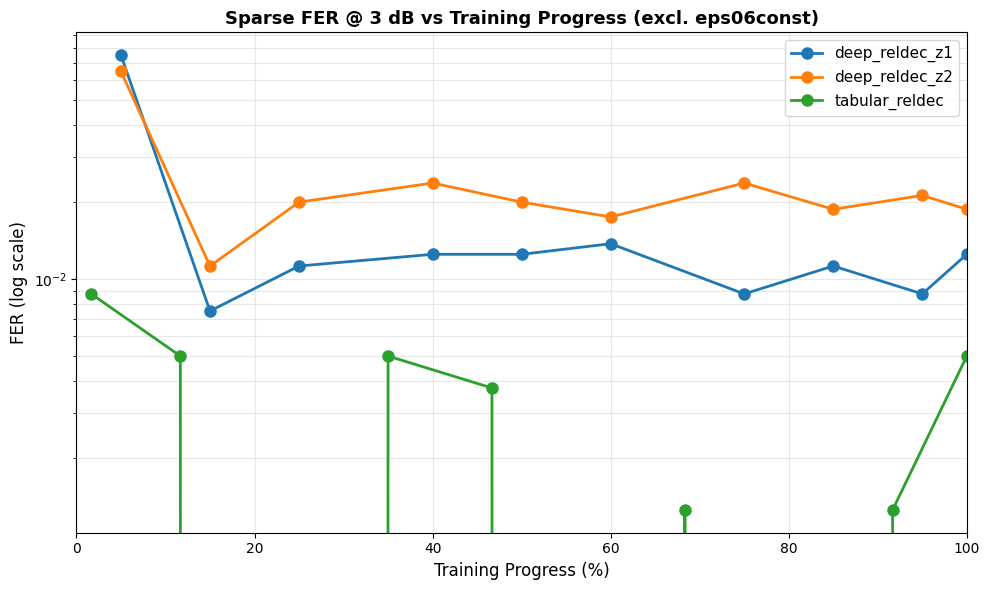

In [32]:
if not sparse_eval_df.empty:
    # Filter to exclude constant-epsilon methods
    sparse_eval_clean = sparse_eval_df[
        ~sparse_eval_df["analysis_method"].str.contains("eps06const", na=False)
    ].copy()
    
    if not sparse_eval_clean.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        for m, g in sparse_eval_clean.groupby("analysis_method"):
            g = g.sort_values("progress")
            ax.semilogy(g["progress_pct"], g["fer"], marker="o", linewidth=2, markersize=8, label=m)

        ax.set_title("Sparse FER @ 3 dB vs Training Progress (excl. eps06const)", fontsize=13, fontweight="bold")
        ax.set_xlabel("Training Progress (%)", fontsize=12)
        ax.set_ylabel("FER (log scale)", fontsize=12)
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3, which="both")
        ax.legend(loc="best", fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print("No data available after filtering out eps06const methods.")
else:
    print("Sparse evaluation data not available.")

In [18]:
# Simple interpretability pass: architecture + salient first-layer input dimensions.
from collections import OrderedDict

if not deep_ckpts_by_method:
    print("No deep checkpoints available for interpretability.")
else:
    interpret_rows = []

    for analysis_method, ckpts in deep_ckpts_by_method.items():
        if not ckpts:
            continue

        final_ck = ckpts[-1]
        ck = load_deep_training_checkpoint(final_ck)
        H = load_parity_check_from_sparse_csv(_resolve_project_path(ck.config.matrix_csv))

        trainer = DeepReldecTrainer(
            h_csr=H,
            dqn_config=ck.dqn_config,
            beta_discount=ck.config.hyperparams.beta,
            l_max=ck.config.hyperparams.l_max,
            device="cpu",
        )
        trainer.import_checkpoint_payload(
            ck.q_online_bytes,
            ck.q_target_bytes,
            ck.optimizer_bytes,
            ck.global_step,
        )

        print("=" * 90)
        print(f"{analysis_method} final checkpoint: {final_ck.name}")
        print(f"episodes_completed={ck.progress.episodes_completed}, global_step={ck.global_step}")
        print("Online network architecture:")
        print(trainer.online_net)

        first_linear = None
        for module in trainer.online_net.modules():
            if isinstance(module, torch.nn.Linear):
                first_linear = module
                break

        if first_linear is None:
            print("No Linear layer found for weight analysis.")
            continue

        W = first_linear.weight.detach().cpu().numpy()  # [hidden, input_dim]
        mean_abs = np.mean(np.abs(W), axis=0)
        topk = min(10, mean_abs.shape[0])
        top_idx = np.argsort(mean_abs)[-topk:][::-1]

        print("Top input dimensions by mean(|W|) in first layer:")
        for rank, idx in enumerate(top_idx, start=1):
            print(f"  {rank:02d}. dim={idx:03d}  mean_abs_w={mean_abs[idx]:.6f}")
            interpret_rows.append({
                "analysis_method": analysis_method,
                "rank": rank,
                "input_dim": int(idx),
                "mean_abs_w": float(mean_abs[idx]),
                "episodes_completed": int(ck.progress.episodes_completed),
            })

    if interpret_rows:
        interpret_df = pd.DataFrame(interpret_rows)
        display(interpret_df.sort_values(["analysis_method", "rank"]))

deep_reldec_z1 final checkpoint: checkpoint_final.npz
episodes_completed=1000, global_step=20000
Online network architecture:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
)
Top input dimensions by mean(|W|) in first layer:
  01. dim=001  mean_abs_w=0.226738
  02. dim=007  mean_abs_w=0.220106
  03. dim=008  mean_abs_w=0.218531
  04. dim=000  mean_abs_w=0.211574
  05. dim=006  mean_abs_w=0.209359
  06. dim=003  mean_abs_w=0.201075
  07. dim=004  mean_abs_w=0.198849
  08. dim=005  mean_abs_w=0.196622
  09. dim=009  mean_abs_w=0.196479
  10. dim=002  mean_abs_w=0.194446
deep_reldec_z2 final checkpoint: checkpoint_final.npz
episodes_completed=1000, global_step=20000
Online network architecture:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
  

,analysis_method,rank,input_dim,mean_abs_w,episodes_completed
0,deep_reldec_z1,1,1,0.226738,1000
1,deep_reldec_z1,2,7,0.220106,1000
2,deep_reldec_z1,3,8,0.218531,1000
3,deep_reldec_z1,4,0,0.211574,1000
4,deep_reldec_z1,5,6,0.209359,1000
5,deep_reldec_z1,6,3,0.201075,1000
6,deep_reldec_z1,7,4,0.198849,1000
7,deep_reldec_z1,8,5,0.196622,1000
8,deep_reldec_z1,9,9,0.196479,1000
9,deep_reldec_z1,10,2,0.194446,1000


In [25]:
# WRAN matrix structural relation analysis: variable-node impact graph and relation properties.
# Relation definition on variable nodes: a R b iff variables a and b participate in at least one common check equation.

from reldec_core import load_parity_check_from_sparse_csv

H_wran = load_parity_check_from_sparse_csv(MATRIX_CSV).tocsr()
H_bin = (H_wran != 0).astype(np.int8).tocsr()
m_checks, n_vars = H_bin.shape

# Variable-to-variable overlap matrix: (i,j) = number of shared checks between variables i and j.
VV_counts = (H_bin.T @ H_bin).toarray().astype(np.int32)

# Binary relation variants.
R_with_diag = VV_counts > 0
R_no_diag = R_with_diag.copy()
np.fill_diagonal(R_no_diag, False)

# Basic graph stats on variable nodes.
var_degree = R_no_diag.sum(axis=1)
shared_wo_diag = VV_counts.copy()
np.fill_diagonal(shared_wo_diag, 0)

# Top hub variables by number of impacted neighbors.
topk = min(12, n_vars)
hub_order = np.argsort(var_degree)[::-1][:topk]
hub_df = pd.DataFrame({
    "var_node": hub_order,
    "impacts_num_vars": var_degree[hub_order],
})

# Strongest pair links by shared-check multiplicity.
upper_i, upper_j = np.triu_indices(n_vars, k=1)
pair_strength = shared_wo_diag[upper_i, upper_j]
nonzero_mask = pair_strength > 0
if np.any(nonzero_mask):
    pair_df = pd.DataFrame({
        "var_a": upper_i[nonzero_mask],
        "var_b": upper_j[nonzero_mask],
        "shared_checks": pair_strength[nonzero_mask],
    }).sort_values(["shared_checks", "var_a", "var_b"], ascending=[False, True, True]).head(15)
else:
    pair_df = pd.DataFrame(columns=["var_a", "var_b", "shared_checks"])

# Relation-property checks.
# 1) Symmetric: R(a,b) => R(b,a)
is_symmetric = np.array_equal(R_no_diag, R_no_diag.T)

# 2) Reflexive (for two relation definitions)
is_reflexive_with_diag = bool(np.all(np.diag(R_with_diag)))
is_reflexive_without_diag = bool(np.all(np.diag(R_no_diag)))

# 3) Transitive: R(a,b) and R(b,c) => R(a,c)
R_int = R_no_diag.astype(np.int8)
R2 = (R_int @ R_int) > 0
is_transitive = bool(np.all((~R2) | R_no_diag))

violations = np.argwhere(R2 & (~R_no_diag))
violations_df = pd.DataFrame(violations[:20], columns=["a", "c"]) if violations.size else pd.DataFrame(columns=["a", "c"])

print("=== WRAN Variable-Node Impact Relation Summary ===")
print(f"H shape: checks={m_checks}, vars={n_vars}")
print(f"Edges in variable-impact graph (undirected): {int(np.triu(R_no_diag, k=1).sum())}")
print(f"Average impacted neighbors per variable: {float(var_degree.mean()):.2f}")
print(f"Min/Max impacted neighbors: {int(var_degree.min())} / {int(var_degree.max())}")
print("")
print("Relation properties (variable-node impact):")
print(f"- Symmetric: {is_symmetric}")
print(f"- Reflexive (with self allowed via shared-check diagonal): {is_reflexive_with_diag}")
print(f"- Reflexive (strict no-self relation): {is_reflexive_without_diag}")
print(f"- Transitive (strict no-self relation): {is_transitive}")
print(f"- Number of transitivity counterexamples: {len(violations)}")

display(hub_df)
display(pair_df)
if not violations_df.empty:
    print("Example transitivity counterexamples (a -> ... -> c exists but a !-> c):")
    display(violations_df)

# Optional: check-node relation as well (checks impact checks if they share at least one variable).
CC_counts = (H_bin @ H_bin.T).toarray().astype(np.int32)
C_with_diag = CC_counts > 0
C_no_diag = C_with_diag.copy()
np.fill_diagonal(C_no_diag, False)

C_int = C_no_diag.astype(np.int8)
C2 = (C_int @ C_int) > 0
check_is_symmetric = np.array_equal(C_no_diag, C_no_diag.T)
check_is_reflexive_with_diag = bool(np.all(np.diag(C_with_diag)))
check_is_reflexive_without_diag = bool(np.all(np.diag(C_no_diag)))
check_is_transitive = bool(np.all((~C2) | C_no_diag))

print("")
print("=== Check-Node Relation (for reference) ===")
print(f"- Symmetric: {check_is_symmetric}")
print(f"- Reflexive (with diagonal): {check_is_reflexive_with_diag}")
print(f"- Reflexive (no-self): {check_is_reflexive_without_diag}")
print(f"- Transitive (no-self): {check_is_transitive}")

=== WRAN Variable-Node Impact Relation Summary ===
H shape: checks=128, vars=384
Edges in variable-impact graph (undirected): 5808
Average impacted neighbors per variable: 30.25
Min/Max impacted neighbors: 18 / 37

Relation properties (variable-node impact):
- Symmetric: True
- Reflexive (with self allowed via shared-check diagonal): True
- Reflexive (strict no-self relation): False
- Transitive (strict no-self relation): False
- Number of transitivity counterexamples: 101744


,var_node,impacts_num_vars
0,64,37
1,65,37
2,66,37
3,67,37
4,68,37
5,69,37
6,70,37
7,71,37
8,72,37
9,73,37


,var_a,var_b,shared_checks
16,0,161,2
52,1,162,2
88,2,163,2
125,3,164,2
161,4,165,2
198,5,166,2
234,6,167,2
270,7,168,2
306,8,169,2
342,9,170,2


Example transitivity counterexamples (a -> ... -> c exists but a !-> c):


,a,c
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4
5,0,5
6,0,6
7,0,7
8,0,8
9,0,9



=== Check-Node Relation (for reference) ===
- Symmetric: True
- Reflexive (with diagonal): True
- Reflexive (no-self): False
- Transitive (no-self): False
